# Pokémon Type Classifier — Model Implementation
# ===================================

## Neural Networks & Deep Learning Project - BBS 25/26

### Damon Caron, Francesco Nisi, Sergio Zuccarello
### ==========================================

In this project, we build a model which guesses the elemental 'type' of Pokémon characters as they appear in the video game franchise, using other independent Pokémon attributes as input features. Our approach involves creating a standard feed-forward neural network using TensorFlow and Keras, in combination with other standard ML libraries such as pandas and scikit-learn for processing, optimization, and evaluation means.

The dataset we are using can be found here:
https://www.kaggle.com/datasets/joshuabetetta/complete-pokedex-v100?select=Complete+Pokedex.csv

AI Disclaimer: We claim that we have used AI ethically in the course of completing this project. While we have employed the help of AI in writing portions of the code, the methodology and ideas which the notebook follows are entirely ours. Additionally, we have clearly labeled any cell in which we utilized AI for writing code with a comment at the top of the cell. In every other case, the code of the cell was written entirely by us.

## Imports

In [ ]:
# pip installs: only run this cell once
!pip install scikit-learn==1.5.2 # for compatibility with scikeras
!pip install scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 42.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
# imports
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import regularizers
from scikeras.wrappers import KerasClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [ ]:
tf.get_logger().setLevel('ERROR')

# Data Loading & Exploration

In [ ]:
data_path = 'complete_pokedex.csv'
df = pd.read_csv(data_path)

In [ ]:
df.head()

,pokedex_number,pokemon_name,type_1,type_2,ability_1,ability_2,ability_3,number_pokemon_with_typing,primary_color,shape,...,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
0,1,Bulbasaur,Grass,Poison,Overgrow,Chlorophyll,NaN,15,Green,Quadruped,...,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
1,2,Ivysaur,Grass,Poison,Overgrow,Chlorophyll,NaN,15,Green,Quadruped,...,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
2,3,Mega Venusaur,Grass,Poison,Thick Fat,NaN,NaN,15,Green,Quadruped,...,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
3,3,Venusaur,Grass,Poison,Overgrow,Chlorophyll,NaN,15,Green,Quadruped,...,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
4,3,Venusaur Gmax,Grass,Poison,Overgrow,Chlorophyll,NaN,15,Green,Quadruped,...,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pokedex_number              1118 non-null   int64  
 1   pokemon_name                1118 non-null   object 
 2   type_1                      1118 non-null   object 
 3   type_2                      597 non-null    object 
 4   ability_1                   1118 non-null   object 
 5   ability_2                   861 non-null    object 
 6   ability_3                   538 non-null    object 
 7   number_pokemon_with_typing  1118 non-null   int64  
 8   primary_color               1118 non-null   object 
 9   shape                       1118 non-null   object 
 10  height                      1118 non-null   float64
 11  weight                      1118 non-null   float64
 12  bmi                         1118 non-null   float64
 13  hit_points                  1118 

In the initial phase of our project, we begin with data loading and exploration by importing the complete Pokédex dataset using the Pandas library. By utilizing standard exploratory functions such as head() and info(), we obtain a comprehensive overview of the dataset's structure, revealing that it consists of 1118 entries and 63 distinct columns. These features include a mix of categorical variables, such as abilities, primary color, and shape, alongside numerical data representing physical traits and base combat stats. During this preliminary inspection, we observed the presence of numerous 'against_*' columns (e.g., against_ground, against_flying), which denote the specific damage multipliers a Pokémon takes from other elemental attacks. We deliberately chose not to consider these columns for our model; since these battle multipliers are strictly deterministic and directly derived from a Pokémon's actual typing—which is the exact target variable we are attempting to classify and predict—including them in our feature set would cause severe data leakage and inevitably lead to redundant results. Therefore, this exploration step helps us identify the true independent variables needed to train a robust and meaningful type classifier.

In [ ]:
# Extract info about our target variables
primary_types = df['type_1']
secondary_types = df['type_2']

unique_types = primary_types.unique()
num_types = primary_types.nunique()
print(f'The {num_types} different Pokemon types are:\n{unique_types}')
print(f'\n\nThere are {int(secondary_types.notnull().sum())} Pokemon in the data set with a secondary type.')

The 18 different Pokemon types are:
['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Dark' 'Poison' 'Electric' 'Ice'
 'Ground' 'Fairy' 'Steel' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Dragon'
 'Flying']


There are 597 Pokemon in the data set with a secondary type.


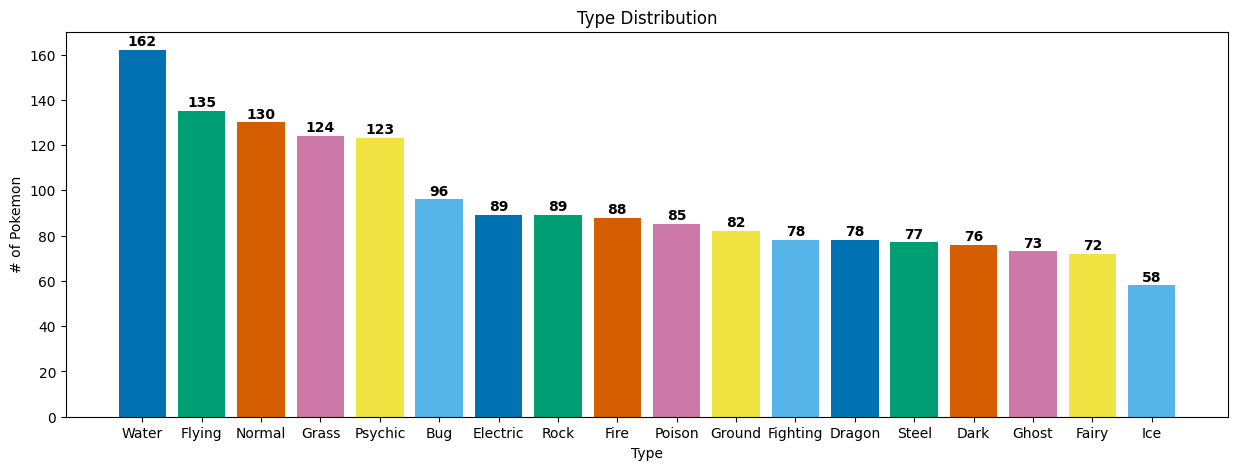

In [ ]:
# Make an array with each occurrence of each type, whether primary or secondary
total_types = pd.concat([primary_types, secondary_types.dropna()], ignore_index=True)
counts = total_types.value_counts()

# Plot the distributions
plt.style.use('seaborn-v0_8-colorblind')
fig, ax = plt.subplots(figsize=(15,5))
padding = 2
for i, count in enumerate(counts):
  ax.bar(counts.index[i], counts.values[i])
  ax.text(i, count+padding, count,
          ha='center', weight='semibold')

ax.set_title("Type Distribution")
ax.set_ylabel("# of Pokemon")
ax.set_xlabel('Type')
plt.show()

Following the initial exploration, we shift our focus to isolating and analyzing our specific target variables: the primary and secondary Pokémon typings (type_1 and type_2). By extracting this information, we confirm there are 18 unique elemental types in our dataset and identify that a substantial number of Pokémon (597) possess dual typing. To get an accurate picture of the overall class balance for our predictive model, we merge both primary and secondary types into a single array, ensuring we drop the null values where a Pokémon only has a single type. We then visualize this aggregated frequency using a bar chart. The resulting plot clearly highlights the distribution of all type occurrences, revealing a noticeable class imbalance. For example, 'Water' is the most heavily represented type with 162 occurrences, while 'Ice' is the rarest with only 58. Recognizing this distribution early on is a crucial step, as we will need to keep this class imbalance in mind during the training phase to prevent our classifier from becoming biased toward the more frequent types.

# Data Preparation

### Preparing the Multi-hot target variable

In [ ]:
# Establish an encoder to use on both type_1 and type_2
type_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
type_encoder.fit(primary_types.values.reshape(-1, 1))

# Encode both target variables
primary_types_enc = type_encoder.transform(primary_types.values.reshape(-1, 1))
secondary_types_enc = type_encoder.transform(secondary_types.values.reshape(-1, 1))

# Combine both one-hot encoded variables into a single multi-hot variable
y = primary_types_enc + secondary_types_enc

Moving into the data preparation phase, we structure our target and feature variables to optimize them for our neural network. First, we tackle the target variable. Since Pokémon can possess up to two types, we utilize a OneHotEncoder on both the primary and secondary types independently, and then add them together to create a single multi-hot encoded array, y. This combination effectively frames our project as a multi-label classification problem.

### Feature Selection & Engineering

In [ ]:
# Disclaimer: The code in this cell was written with the assistance of AI
# Features in which we want to be able to find trends
features = ['hit_points', 'attack', 'defense', 'special_attack', 'special_defense',
            'speed', 'total_stats', 'bmi', 'legendary', 'primary_color', 'shape']

X = df[features].copy()

# Creation of mathematical ratios to help identify different Pokemon "roles"
X['phys_ratio'] = X['attack'] / (X['defense'] + 1)
X['spec_ratio'] = X['special_attack'] / (X['special_defense'] + 1)
X['bulk'] = X['hit_points'] + X['defense'] + X['special_defense']

# More ratios to quantify different stat trends
X['atk_special_bias'] = X['attack'] / (X['special_attack'] + 1)
X['def_special_bias'] = X['defense'] / (X['special_defense'] + 1)
X['phys_tankiness'] = X['hit_points'] * X['defense']
X['spec_tankiness'] = X['hit_points'] * X['special_defense']

# Consider each stat is a percentage of total stats
for stat in ['hit_points', 'attack', 'defense', 'special_attack', 'special_defense', 'speed']:
    X[f'{stat}_pct'] = X[stat] / (X['total_stats'] + 1)

# Transform categorical variables into one-hot-encoded variables
X = pd.get_dummies(X, columns=['primary_color', 'shape'], prefix=['color', 'shape'])

# Convert boolean feature to int
X['legendary'] = X['legendary'].astype(int)

# Drop raw stats
X = X.drop(columns=['hit_points', 'attack', 'defense', 'special_attack', 'special_defense', 'speed'])

Next, we focus on feature selection and engineering to extract more meaningful patterns from the data. We select core attributes like base combat stats, BMI, legendary status, color, and shape. Instead of simply feeding the raw numerical stats into the model, we engineer several mathematical ratios—such as physical-to-special biases and overall "bulk" or "tankiness"—to help the classifier recognize distinct "roles" a Pokémon might fulfill. We also normalize the stats by converting them into percentages of the Pokémon's total stats, taking care to add 1 to our denominators to prevent division by zero errors. After generating these insightful new features, we drop the original raw stat columns to minimize data redundancy. We then wrap up our feature engineering by one-hot encoding the categorical 'color' and 'shape' variables and converting the boolean 'legendary' flag into a standard integer.

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=df['type_1'])

Finally, with our dataset fully preprocessed, we perform a standard 80/20 train-test split. We make sure to use the stratify parameter based on the primary type. This ensures that both our training and testing sets accurately reflect the uneven class distribution we identified in the previous step, preventing our model from training on unrepresentative samples. While we would have liked to stratify based on both type_1 and type_2, since both are equally valid target labels, there would be some complications in trying to implement this. If we wanted to stratify on the concatenation of the type_1 and type_2 columns (i.e. total_types), we would run into indexing issues. On the other hand, stratifying on the union of type_1 and type_2 for each data point would also not be applicable in this case since our model is trying to predict *either* label, not both. Additionally, there may be some Pokémon in the dataset with rare or even unique type combinations, which may cause some unwanted effects in the stratification process. For these reasons, we opted to go with the simplest approach of only stratifying with respect to the primary type of each Pokémon. Though this approach does not 100% accurately reflect the distribution of all types across the dataset, we believe it to be the best option in this scenario.

### Preprocessing setup

In [ ]:
X.columns

Index(['total_stats', 'bmi', 'legendary', 'phys_ratio', 'spec_ratio', 'bulk',
       'atk_special_bias', 'def_special_bias', 'phys_tankiness',
       'spec_tankiness', 'hit_points_pct', 'attack_pct', 'defense_pct',
       'special_attack_pct', 'special_defense_pct', 'speed_pct', 'color_Black',
       'color_Blue', 'color_Brown', 'color_Gray', 'color_Green', 'color_Pink',
       'color_Purple', 'color_Red', 'color_White', 'color_Yellow',
       'shape_Armor', 'shape_Arms', 'shape_Ball', 'shape_Blob',
       'shape_Bug-Wings', 'shape_Fish', 'shape_Heads', 'shape_Humanoid',
       'shape_Legs', 'shape_Quadruped', 'shape_Squiggle', 'shape_Tentacles',
       'shape_Upright', 'shape_Wings'],
      dtype='object')

In [ ]:
# Seperate numeric features for scaling
numeric_cols = ['total_stats', 'bmi', 'phys_ratio', 'spec_ratio', 'bulk',
       'atk_special_bias', 'def_special_bias', 'phys_tankiness',
       'spec_tankiness', 'hit_points_pct', 'attack_pct', 'defense_pct',
       'special_attack_pct', 'special_defense_pct', 'speed_pct']
cat_cols = ['legendary', 'color_Black',
       'color_Blue', 'color_Brown', 'color_Gray', 'color_Green', 'color_Pink',
       'color_Purple', 'color_Red', 'color_White', 'color_Yellow',
       'shape_Armor', 'shape_Arms', 'shape_Ball', 'shape_Blob',
       'shape_Bug-Wings', 'shape_Fish', 'shape_Heads', 'shape_Humanoid',
       'shape_Legs', 'shape_Quadruped', 'shape_Squiggle', 'shape_Tentacles',
       'shape_Upright', 'shape_Wings']

Moving into the final preprocessing setup before building our neural network, we need to ensure our newly engineered data is properly scaled. We start by reviewing the complete list of features in our dataset (X.columns). To handle these features correctly, we divide them into two groups: numeric_cols (continuous variables like our engineered stat ratios, percentages, and BMI) and cat_cols (our binary and one-hot encoded variables representing color, shape, and legendary status).

In [ ]:
# Will scale input data in the pipeline later
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numeric_cols),
        ("categorical", "passthrough", cat_cols)
    ]
)

Because deep learning models are highly sensitive to the scale of input data, we utilize a ColumnTransformer to manage our preprocessing operations efficiently. We apply a StandardScaler() exclusively to our numeric_cols. This standardizes our continuous values, which helps the neural network converge faster and prevents features with larger numerical ranges from disproportionately influencing the model's weights. Conversely, we apply the "passthrough" instruction to our cat_cols, leaving them entirely untouched. This preprocessor object will later be integrated into our training pipeline.

# Building Our Model

In [ ]:
# Disclaimer: The code in this cell was written with the assistance of AI
# Custom loss function
# Mathematically equivalent to -log(dot product of softmax(logits) & multi-hot label)
# Reduces to cce if there is only one valid label
def multi_valid_ce(y_true, logits):
    log_probs = tf.nn.log_softmax(logits, axis=-1)
    masked = log_probs + tf.math.log(y_true)
    return -tf.reduce_logsumexp(masked, axis=-1)

Moving into the core of our model architecture, we define custom loss and accuracy metrics tailored specifically to the multi-label nature of Pokémon typings. Standard categorical metrics fall short here because a Pokémon can have up to two valid types, and we want our model to be rewarded if its single top prediction matches either of those true types. First, we implement a custom loss function, multi_valid_ce. This function calculates a specialized cross-entropy that evaluates the predicted log probabilities strictly against our multi-hot labels, smoothly reducing to standard categorical cross-entropy when evaluating single-typed Pokémon.

In [ ]:
# Disclaimer: The code in this cell was written with the assistance of AI
# Custom Accuracy Metric
# Checks argmax of logits against either valid type encoding
class MultiValidAccuracy(tf.keras.metrics.Metric):
    def __init__(self, name="multi_valid_accuracy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total = self.add_weight(name="total", initializer="zeros")
        self.correct = self.add_weight(name="correct", initializer="zeros")

    def update_state(self, y_true, logits, sample_weight=None):
        # 1. Model's single-class prediction
        preds = tf.argmax(logits, axis=-1)        # (batch,)

        # 2. Was that index marked as valid in the multi-hot label?
        is_valid = tf.gather(y_true, preds, batch_dims=1)  # (batch,)

        # 3. Accumulate
        self.correct.assign_add(tf.reduce_sum(is_valid))
        self.total.assign_add(tf.cast(tf.size(preds), tf.float32))

    def result(self):
        return self.correct / (self.total + 1e-7)

    def reset_states(self):
        self.total.assign(0.0)
        self.correct.assign(0.0)


Next, we construct a custom Keras metric class, MultiValidAccuracy. Instead of demanding an exact match for all types, this metric isolates the model's highest-confidence prediction using argmax and verifies if that specific predicted class is marked as valid within the true multi-hot array, dynamically updating our accuracy state during training.

In [ ]:
# Disclaimer: The code in this cell was written with the assistance of AI
# Equivalent scorer to be used in sklearn
def multi_valid_accuracy(y_true, y_pred):
    """
    y_true: shape (n_samples, n_classes), multi-hot encoded
    y_pred: shape (n_samples, n_classes), predicted probabilities or logits
    """
    # Step 1: get argmax of predictions
    preds = np.argmax(y_pred, axis=1)  # (n_samples,)

    # Step 2: check if prediction is valid according to multi-hot label
    is_valid = y_true[np.arange(len(preds)), preds]  # boolean/int array

    # Step 3: compute accuracy
    return np.sum(is_valid) / len(preds)

multi_valid_scorer = make_scorer(multi_valid_accuracy, greater_is_better=True)

Finally, to ensure perfect consistency across our entire machine learning pipeline, we replicate this accuracy logic using NumPy operations and wrap it with make_scorer. This step allows us to seamlessly utilize our custom multi-valid accuracy metric during any scikit-learn cross-validation or hyperparameter search processes.

In [ ]:
# Function to create model
# In our testing, we started seeing diminishing returns after 2 hidden layers
def create_model(learning_rate=0.001, dropout_rate=0.2, units=64, l2_penalty=0.01):
  model = Sequential([
      Dense(units, activation='relu', input_shape=(X_train.shape[1],),
            kernel_regularizer=regularizers.L2(l2_penalty)),
      BatchNormalization(),
      Dropout(dropout_rate),

      # Second layer scales down based on the first layer's units
      Dense(max(16, units // 2), activation='relu',
            kernel_regularizer=regularizers.L2(l2_penalty)),
      BatchNormalization(),
      Dropout(dropout_rate),

      Dense(num_types)
  ])

  model.compile(optimizer=Adam(learning_rate=learning_rate),
                loss=multi_valid_ce,
                metrics=[MultiValidAccuracy()])

  return model

In this section, we define the architecture of our neural network by encapsulating it within a create_model function, which allows us to easily experiment with hyperparameters like learning rate, dropout rate, and layer units later on. Based on our preliminary testing, we noticed diminishing returns when adding more than two hidden layers, so we opted for a relatively shallow but robust Sequential model. Our first hidden layer is a Dense layer utilizing a ReLU activation function, and to actively prevent overfitting, we apply an L2 weight penalty, followed immediately by BatchNormalization to stabilize the learning process, and a Dropout layer. The second hidden layer mirrors this exact regularization structure but scales down the number of neurons by half, ensuring it never drops below 16 units, which creates a funnel effect that forces the network to compress the data and extract only the most critical features. Finally, our output layer is a simple Dense layer with a number of units equal to our unique Pokémon types; crucially, we leave this layer without an activation function so it outputs raw logits, which feed perfectly into the custom multi_valid_ce loss function we designed previously. We wrap up by compiling the model using the Adam optimizer, successfully tying together our custom multi-label loss and accuracy metrics to guide the training process.

In [ ]:
# Early stopping to optimize training and combat overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

In [ ]:
# Use sklearn wrapper for compatibility with pipeline
clf = KerasClassifier(
    model=create_model,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    dropout_rate=0.2,
    l2_penalty=0.01,
    learning_rate=0.001,
    units=64,
    class_weight='balanced',
    verbose=0
)

In [ ]:
# Build pipeline
poke_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", clf)
])

In [ ]:
# Define the parameter grid
param_grid = {
    'model__learning_rate': [0.001, 0.0005],
    'model__dropout_rate':  [0.2, 0.4],
    'model__units':         [32, 64],
    'model__l2_penalty':    [0.01, 0.0001]
}

In [ ]:
grid = GridSearchCV(
    poke_pipeline,
    param_grid,
    cv=3,
    scoring=multi_valid_scorer
)

In [ ]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
grid.fit(X_train_df, y_train)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         StandardScaler(),
                                                                         ['total_stats',
                                                                          'bmi',
                                                                          'phys_ratio',
                                                                          'spec_ratio',
                                                                          'bulk',
                                                                          'atk_special_bias',
                                                                          'def_special_bias',
                                                                          'phys_tankiness',
                                                                          'spec_tankiness',
                                                                          'hit_points_pct',
                                                                          'attack_pct',
                                                                          'defense_pct',
                                                                          'special_attack_pct',
                                                                          'special_defense_pct',
                                                                          'speed_pct']),
                                                                        ('c...
                                        KerasClassifier(batch_size=32, class_weight='balanced', dropout_rate=0.2, epochs=200, l2_penalty=0.01, learning_rate=0.001, model=<function create_model at 0x7c8c265cf740>, units=64, validation_split=0.2, verbose=0))]),
             param_grid={'model__dropout_rate': [0.2, 0.4],
                         'model__l2_penalty': [0.01, 0.0001],
                         'model__learning_rate': [0.001, 0.0005],
                         'model__units': [32, 64]},
             scoring=make_scorer(multi_valid_accuracy, response_method='predict'))

Moving into the training and optimization phase, we first implement an EarlyStopping callback to closely monitor our validation loss, ensuring we halt training if the model stops improving for 15 epochs while restoring the best performing weights to actively combat overfitting. To integrate our neural network with scikit-learn's libraries, we wrap it using a KerasClassifier, passing in our base hyperparameters and setting class_weight to 'balanced' to directly address the class imbalance we identified during our initial data exploration. We then construct a unified Pipeline that chains our previously defined data preprocessor directly to this classifier, which guarantees that our scaling and encoding steps are applied inside each fold of cross-validation without causing data leakage. Next, we define a comprehensive parameter grid containing various combinations of learning rates, dropout rates, layer units, and L2 penalties to explore. We feed this grid and our pipeline into a GridSearchCV , utilizing 3-fold cross-validation and our custom multi_valid_scorer metric to evaluate every single architectural combination. Finally, we convert our training array back into a structured DataFrame to safely preserve the column names for our preprocessor, and execute grid.fit to launch the automated training and hyperparameter tuning process, yielding the most optimal version of our Pokémon type predictor.

# Evaluation

In [ ]:
test_accuracy = grid.score(X_test, y_test)
print(f"\nTest Set Accuracy: {test_accuracy*100:.2f}%")

train_accuracy = grid.score(X_train, y_train)
print(f"\nTrain Set Accuracy: {train_accuracy*100:.2f}%")


Test Set Accuracy: 50.89%

Train Set Accuracy: 69.69%


In [ ]:
# Disclaimer: The code in this cell was written with the assistance of AI
# want to "unroll" our multihot labels to make them suitable for confusion matrix analysis
def expand_multivalid_labels(y_true, logits):
    """
    Expands multi-hot labels so each valid class becomes a separate row.

    Parameters
    ----------
    y_true : array (N, C)
        Multi-hot label matrix.
    logits : array (N, C)
        Model outputs.

    Returns
    -------
    y_true_exp : (M,) integer class labels
    y_pred_exp : (M,) integer predicted labels
    """

    y_pred = np.argmax(logits, axis=1)

    y_true_exp = []
    y_pred_exp = []

    for i in range(len(y_true)):
        valid_classes = np.where(y_true[i] == 1)[0]

        for cls in valid_classes:
            y_true_exp.append(cls)
            y_pred_exp.append(y_pred[i])

    return np.array(y_true_exp), np.array(y_pred_exp)

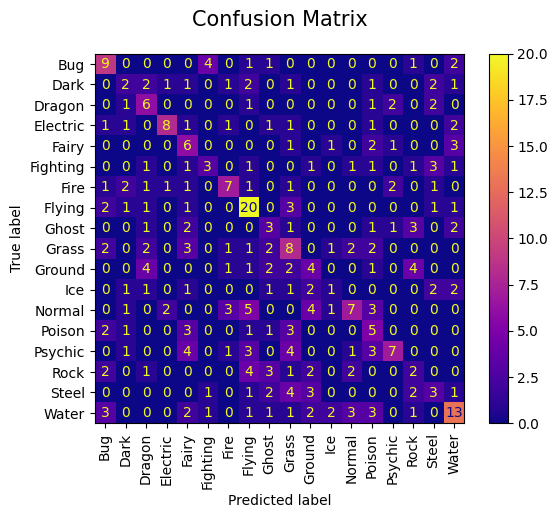

<Figure size 3000x2000 with 0 Axes>

In [ ]:
# Generate Confusion Matrix
logits = grid.predict(X_test)
y_true, y_pred = expand_multivalid_labels(y_test, logits)
cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_types))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=type_encoder.categories_[0])
disp.plot(cmap=plt.cm.plasma)
disp.ax_.tick_params(axis='x', labelrotation=90)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.figure(figsize=(30,20))
plt.show()

In the final evaluation phase, we assess the performance of our best model discovered during the grid search. We first compute our custom multi-valid accuracy on both the training and test sets, yielding ~70% and ~50% respectively; while this gap indicates some residual overfitting despite our regularization efforts, achieving a 50% accuracy is actually quite reasonable given the inherent difficulty of predicting among 18 heavily overlapping classes based solely on raw stats and physical characteristics. To gain deeper insights into exactly where our classifier succeeds or fails, we visualize its predictions using a confusion matrix. Because standard metric functions cannot natively process our multi-hot encoded target variables, we engineer a custom expand_multivalid_labels function to "unroll" the data, essentially mapping the model's single highest-confidence prediction against every valid true class a Pokémon possesses as a separate row. After generating and plotting the matrix, the resulting heatmap clearly highlights our model's behavior. The bright spots along the diagonal indicate strong predictive accuracy for highly populated and distinct types like Water, Flying, Grass, and Fire, whereas the scattered off-diagonal values reveal the rarer types that are most frequently confused with one another due to shared statistical roles or physical traits.

# Interactive Model Prediction Output

This final section is a fun extra component to let you see our model in action. To create an interactive output, we reconstruct our training and testing dataframes to include the Pokemon names. We define a new function, guess_type, which takes a string input. The function searches the dataset, informs the user if the specific Pokemon belongs to the training or testing set, extracts the relevant features, and prints the predicted type. We demonstrate this with 'Pikachu', and the model predicts 'Electric'. To encourage interaction, we display an array of names from the test data. These represent unseen Pokemon, making them excellent candidates for user testing.

In [ ]:
## reconstruct train and text with names
X_train_named = X_train.copy()
X_test_named = X_test.copy()

X_train_named['pokemon_name'] = df['pokemon_name'].str.lower()
X_test_named['pokemon_name'] = df['pokemon_name'].str.lower()

# define function to guess type based on Pokemon name
def guess_type(mon2guess: str):
  # change string to lower case
  mon2guess = mon2guess.lower()
  relevant_set = None

  # check if mon is in the test set
  if mon2guess in X_test_named['pokemon_name'].values:
    print(f'Pokemon {mon2guess} found in test set.')
    relevant_set = X_test_named

  # else check if mon is in the train set
  elif mon2guess in X_train_named['pokemon_name'].values:
    print(f'Pokemon {mon2guess} found in training set.')
    relevant_set = X_train_named

  # else mon does not exist
  else:
    print(f'Pokemon {mon2guess} not found in dataset.')
    return

  # give type prediction
  print(f'The model predicts that {mon2guess} has type:')
  print(type_encoder.categories_[0][int(np.argmax(grid.predict(relevant_set.loc[relevant_set['pokemon_name']==mon2guess])))])

In [ ]:
guess_type('Pikachu')

Pokemon pikachu found in training set.
The model predicts that pikachu has type:
Electric


In [ ]:
# list of Pokemon that the current model hasn't seen
# test out these names in the cell above!
X_test_named['pokemon_name'].values

array(['corvisquire', 'registeel', 'golduck', 'primal groudon', 'woobat',
       'oricorio baile style', 'kadabra', 'flabebe', 'galarian slowking',
       'giratina altered', 'natu', 'anorith', 'larvesta',
       'gumshoos totem', 'mega mewtwo y', 'spinda', 'luxio', 'gothorita',
       'hydreigon', 'zygarde ten percent', 'croconaw', 'morelull',
       'galarian slowbro', 'alolan dugtrio', 'charmeleon', 'weepinbell',
       'mandibuzz', 'shellder', 'lucario', 'magnezone', 'latios',
       'flygon', 'kricketot', 'guzzlord', 'sewaddle', 'munchlax',
       'lapras gmax', 'yamper', 'grookey', 'mimikyu totem disguised',
       'throh', 'minun', 'durant', 'gogoat', 'leafeon', 'indeedee female',
       'pidgeotto', 'charmander', 'mega rayquaza', 'piloswine',
       'cacturne', 'granbull', 'wormadam sandy cloak', 'muk',
       'perrserker', 'ditto', 'scraggy', 'meowth gmax', 'pansear',
       'druddigon', 'rockruff', 'meditite', 'meltan', 'slowpoke', 'ho-oh',
       'golbat', 'regice', 'galaria